Puedes pedir las versiones impresa y ebook de *Think Python 3e* en
[Bookshop.org](https://bookshop.org/a/98697/9781098155438) y
[Amazon](https://www.amazon.com/_/dp/1098155432?smid=ATVPDKIKX0DER&_encoding=UTF8&tag=oreilly20-20&_encoding=UTF8&tag=greenteapre01-20&linkCode=ur2&linkId=e2a529f94920295d27ec8a06e757dc7c&camp=1789&creative=9325).

In [1]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + str(local))
    return filename

download('https://github.com/AllenDowney/ThinkPython/raw/v3/thinkpython.py');
download('https://github.com/AllenDowney/ThinkPython/raw/v3/diagram.py');

import thinkpython

Downloaded thinkpython.py
Downloaded diagram.py


# Listas

Este capítulo presenta uno de los tipos integrados más útiles de Python: las listas.
También aprenderás más sobre objetos y lo que puede ocurrir cuando varias variables se refieren al mismo objeto.

En los ejercicios al final del capítulo, construiremos una lista de palabras y la usaremos para buscar palabras especiales como palíndromos y anagramas.

## Una lista es una secuencia

Como un string, una **lista** es una secuencia de valores. En un string, los
valores son caracteres; en una lista, pueden ser de cualquier tipo.
Los valores en una lista se llaman **elementos**.

Hay varias formas de crear una nueva lista; la más simple es encerrar los elementos entre corchetes (`[` y `]`).
Por ejemplo, aquí tienes una lista de dos enteros.

In [3]:
numbers = [42, 123]

Y aquí tienes una lista de tres strings.

In [4]:
cheeses = ['Cheddar', 'Edam', 'Gouda']

Los elementos de una lista no tienen que ser del mismo tipo.
La siguiente lista contiene un string, un float, un entero e incluso otra lista.

In [5]:
t = ['spam', 2.0, 5, [10, 20]]

Una lista dentro de otra lista está **anidada**.

Una lista que no contiene elementos se llama lista vacía; puedes crear
una con corchetes vacíos, `[]`.

In [6]:
empty = []

La función `len` devuelve la longitud de una lista.

In [7]:
len(cheeses)

3

La longitud de una lista vacía es `0`.

In [8]:
len(empty)

0

La siguiente figura muestra el diagrama de estado de `cheeses`, `numbers` y `empty`.

In [9]:
from diagram import make_list, Binding, Value

list1 = make_list(cheeses, dy=-0.3, offsetx=0.17)
binding1 = Binding(Value('cheeses'), list1)

list2 = make_list(numbers, dy=-0.3, offsetx=0.17)
binding2 = Binding(Value('numbers'), list2)

list3 = make_list(empty, dy=-0.3, offsetx=0.1)
binding3 = Binding(Value('empty'), list3)

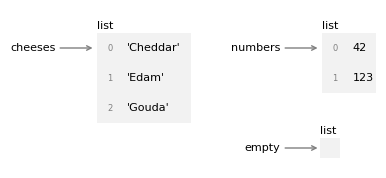

In [10]:
from diagram import diagram, adjust, Bbox

width, height, x, y = [3.66, 1.58, 0.45, 1.2]
ax = diagram(width, height)
bbox1 = binding1.draw(ax, x, y)
bbox2 = binding2.draw(ax, x+2.25, y)
bbox3 = binding3.draw(ax, x+2.25, y-1.0)

bbox = Bbox.union([bbox1, bbox2, bbox3])
#adjust(x, y, bbox)

Las listas se representan con cajas con la palabra "lista" fuera y los elementos numerados de la lista dentro.

## Las listas son mutables

Para leer un elemento de una lista, podemos usar el operador de corchetes.
El índice del primer elemento es `0`.

In [11]:
cheeses[0]

'Cheddar'

A diferencia de los strings, las listas son mutables. Cuando el operador de corchetes aparece en
el lado izquierdo de una asignación, identifica el elemento de la lista
al que se asignará el valor.

In [12]:
numbers[1] = 17
numbers

[42, 17]

El segundo elemento de `numbers`, que antes era `123`, ahora es `17`.

Los índices de lista funcionan igual que los índices de string:

-   Cualquier expresión entera puede usarse como índice.

-   Si intentas leer o escribir un elemento que no existe, obtienes
    un `IndexError`.

-   Si un índice tiene un valor negativo, cuenta hacia atrás desde el final de
    la lista.

El operador `in` funciona con listas: comprueba si un elemento dado aparece en algún lugar de la lista.

In [13]:
'Edam' in cheeses

True

In [14]:
'Wensleydale' in cheeses

False

Aunque una lista puede contener otra lista, la lista anidada sigue contando como un solo elemento; por eso, en la siguiente lista, solo hay cuatro elementos.

In [15]:
t = ['spam', 2.0, 5, [10, 20]]
len(t)

4

Y `10` no se considera un elemento de `t` porque es un elemento de una lista anidada, no de `t`.

In [16]:
10 in t

False

## Porciones de lista

El operador de porción funciona con listas igual que con strings.
El siguiente ejemplo selecciona el segundo y el tercer elemento de una lista de cuatro letras.

In [17]:
letters = ['a', 'b', 'c', 'd']
letters[1:3]

['b', 'c']

Si omites el primer índice, la porción empieza al principio.

In [18]:
letters[:2]

['a', 'b']

Si omites el segundo, la porción llega hasta el final.

In [19]:
letters[2:]

['c', 'd']

Así que, si omites ambos, la porción es una copia de toda la lista.

In [20]:
letters[:]

['a', 'b', 'c', 'd']

Otra forma de copiar una lista es usar la función `list`.

In [21]:
list(letters)

['a', 'b', 'c', 'd']

Como `list` es el nombre de una función integrada, deberías evitar usarlo como nombre de variable.


## Operaciones con listas

El operador `+` concatena listas.

In [22]:
t1 = [1, 2]
t2 = [3, 4]
t1 + t2

[1, 2, 3, 4]

El operador `*` repite una lista un número determinado de veces.

In [23]:
['spam'] * 4

['spam', 'spam', 'spam', 'spam']

Ningún otro operador matemático funciona con listas, pero la función integrada `sum` suma los elementos.

In [24]:
sum(t1)

3

Y `min` y `max` encuentran el elemento más pequeño y el más grande.

In [25]:
min(t1)

1

In [26]:
max(t2)

4

## Métodos de lista

Python proporciona métodos que operan sobre listas. Por ejemplo, `append`
añade un nuevo elemento al final de una lista:

In [27]:
letters.append('e')
letters

['a', 'b', 'c', 'd', 'e']

`extend` toma una lista como argumento y añade todos sus elementos:

In [28]:
letters.extend(['f', 'g'])
letters

['a', 'b', 'c', 'd', 'e', 'f', 'g']

Hay dos métodos que eliminan elementos de una lista.
Si conoces el índice del elemento que quieres, puedes usar `pop`.

In [29]:
t = ['a', 'b', 'c']
t.pop(1)

'b'

El valor de retorno es el elemento que se eliminó.
Y podemos confirmar que la lista se ha modificado.

In [30]:
t

['a', 'c']

Si conoces el elemento que quieres eliminar (pero no el índice), puedes usar `remove`:

In [31]:
t = ['a', 'b', 'c']
t.remove('b')

El valor de retorno de `remove` es `None`.
Pero podemos confirmar que la lista se ha modificado.

In [32]:
t

['a', 'c']

Si el elemento que pides no está en la lista, eso es un ValueError.

In [33]:
%%expect ValueError

t.remove('d')

ValueError: list.remove(x): x not in list

## Listas y strings

Un string es una secuencia de caracteres y una lista es una secuencia de valores,
pero una lista de caracteres no es lo mismo que un string.
Para convertir un string en una lista de caracteres, puedes usar la función `list`.

In [34]:
s = 'spam'
t = list(s)
t

['s', 'p', 'a', 'm']

La función `list` divide un string en letras individuales.
Si quieres dividir un string en palabras, puedes usar el método `split`:

In [35]:
s = 'pining for the fjords'
t = s.split()
t

['pining', 'for', 'the', 'fjords']

Un argumento opcional llamado **delimitador** especifica qué caracteres se usan como límites entre palabras. El siguiente ejemplo usa un guion como delimitador.

In [36]:
s = 'ex-parrot'
t = s.split('-')
t

['ex', 'parrot']

Si tienes una lista de strings, puedes concatenarlos en un solo string usando `join`.
`join` es un método de string, así que tienes que invocarlo sobre el delimitador y pasar la lista como argumento.

In [37]:
delimiter = ' '
t = ['pining', 'for', 'the', 'fjords']
s = delimiter.join(t)
s

'pining for the fjords'

En este caso el delimitador es un carácter de espacio, así que `join` pone un espacio
entre las palabras.
Para unir strings sin espacios, puedes usar el string vacío, `''`, como delimitador.

## Recorrer una lista con un bucle

Puedes usar una sentencia `for` para recorrer los elementos de una lista.

In [38]:
for cheese in cheeses:
    print(cheese)

Cheddar
Edam
Gouda


Por ejemplo, después de usar `split` para crear una lista de palabras, podemos usar `for` para recorrerlas.

In [39]:
s = 'pining for the fjords'

for word in s.split():
    print(word)

pining
for
the
fjords


Un bucle `for` sobre una lista vacía nunca ejecuta las sentencias indentadas.

In [40]:
for x in []:
    print('This never happens.')

## Ordenar listas

Python proporciona una función integrada llamada `sorted` que ordena los elementos de una lista.

In [41]:
scramble = ['c', 'a', 'b']
sorted(scramble)

['a', 'b', 'c']

La lista original no cambia.

In [42]:
scramble

['c', 'a', 'b']

`sorted` funciona con cualquier tipo de secuencia, no solo con listas. Así que podemos ordenar las letras de un string así.

In [43]:
sorted('letters')

['e', 'e', 'l', 'r', 's', 't', 't']

El resultado es una lista.
Para convertir la lista en un string, podemos usar `join`.

In [44]:
''.join(sorted('letters'))

'eelrstt'

Con un string vacío como delimitador, los elementos de la lista se unen sin nada entre ellos.

## Objetos y valores

Si ejecutamos estas sentencias de asignación:

In [45]:
a = 'banana'
b = 'banana'

Sabemos que `a` y `b` se refieren ambos a un string, pero no sabemos si se refieren al *mismo* string.
Hay dos estados posibles, mostrados en la siguiente figura.

In [46]:
from diagram import Frame, Stack

s = 'banana'
bindings = [Binding(Value(name), Value(repr(s))) for name in 'ab']
frame1 = Frame(bindings, dy=-0.25)

binding1 = Binding(Value('a'), Value(repr(s)), dy=-0.11)
binding2 = Binding(Value('b'), draw_value=False, dy=0.11)
frame2 = Frame([binding1, binding2], dy=-0.25)

stack = Stack([frame1, frame2], dx=1.7, dy=0)

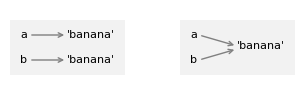

In [47]:
width, height, x, y = [2.85, 0.76, 0.17, 0.51]
ax = diagram(width, height)
bbox = stack.draw(ax, x, y)
# adjust(x, y, bbox)

En el diagrama de la izquierda, `a` y `b` se refieren a dos objetos diferentes que tienen el
mismo valor. En el diagrama de la derecha, se refieren al mismo objeto.
Para comprobar si dos variables se refieren al mismo objeto, puedes usar el operador `is`.

In [48]:
a = 'banana'
b = 'banana'
a is b

True

En este ejemplo, Python solo creó un objeto string, y tanto `a`
como `b` se refieren a él.
Pero cuando creas dos listas, obtienes dos objetos.

In [49]:
a = [1, 2, 3]
b = [1, 2, 3]
a is b

False

Así que el diagrama de estado se ve así.

In [50]:
t = [1, 2, 3]
binding1 = Binding(Value('a'), Value(repr(t)))
binding2 = Binding(Value('b'), Value(repr(t)))
frame = Frame([binding1, binding2], dy=-0.25)

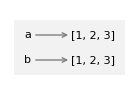

In [51]:
width, height, x, y = [1.16, 0.76, 0.21, 0.51]
ax = diagram(width, height)
bbox = frame.draw(ax, x, y)
# adjust(x, y, bbox)

En este caso diríamos que las dos listas son **equivalentes**, porque tienen los mismos elementos, pero no **idénticos**, porque no son el mismo objeto.
Si dos objetos son idénticos, también son equivalentes, pero si son equivalentes, no necesariamente son idénticos.

## Aliasing

Si `a` se refiere a un objeto y asignas `b = a`, entonces ambas variables se refieren al mismo objeto.

In [52]:
a = [1, 2, 3]
b = a
b is a

True

Así que el diagrama de estado se ve así.

In [53]:
t = [1, 2, 3]
binding1 = Binding(Value('a'), Value(repr(t)), dy=-0.11)
binding2 = Binding(Value('b'), draw_value=False, dy=0.11)
frame = Frame([binding1, binding2], dy=-0.25)

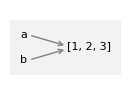

In [54]:
width, height, x, y = [1.11, 0.81, 0.17, 0.56]
ax = diagram(width, height)
bbox = frame.draw(ax, x, y)
# adjust(x, y, bbox)

La asociación de una variable con un objeto se llama **referencia**.
En este ejemplo, hay dos referencias al mismo objeto.

Un objeto con más de una referencia tiene más de un nombre, así que decimos que el objeto está **aliased**.
Si el aliased objeto es mutable, los cambios hechos con un nombre afectan al otro.
En este ejemplo, si cambiamos el objeto al que se refiere `b`, también estamos cambiando el objeto al que se refiere `a`.

In [55]:
b[0] = 5
a

[5, 2, 3]

Así que diríamos que `a` "ve" este cambio.
Aunque este comportamiento puede ser útil, es propenso a errores.
En general, es más seguro evitar el aliasing cuando trabajas con objetos mutables.

Para objetos inmutables como strings, el aliasing no supone tanto problema.
En este ejemplo:

In [56]:
a = 'banana'
b = 'banana'

Casi nunca importa si `a` y `b` se refieren al mismo
string o no.

## Listas como argumentos

Cuando pasas una lista a una función, la función recibe una referencia a la
lista. Si la función modifica la lista, el código que llama ve el cambio. Por
ejemplo, `pop_first` usa el método de lista `pop` para eliminar el primer elemento de una lista.

In [57]:
def pop_first(lst):
    return lst.pop(0)

Podemos usarla así.

In [58]:
letters = ['a', 'b', 'c']
pop_first(letters)

'a'

El valor de retorno es el primer elemento, que se ha eliminado de la lista, como podemos ver al mostrar la lista modificada.

In [59]:
letters

['b', 'c']

En este ejemplo, el parameter `lst` y la variable `letters` son aliases del mismo objeto, así que el diagrama de estado se ve así:

In [60]:
lst = make_list('abc', dy=-0.3, offsetx=0.1)
binding1 = Binding(Value('letters'), draw_value=False)
frame1 = Frame([binding1], name='__main__', loc='left')

binding2 = Binding(Value('lst'), draw_value=False, dx=0.61, dy=0.35)
frame2 = Frame([binding2], name='pop_first', loc='left', offsetx=0.08)

stack = Stack([frame1, frame2], dx=-0.3, dy=-0.5)

[np.float64(2.05), np.float64(1.22), np.float64(1.06), np.float64(0.85)]

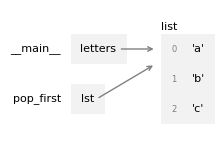

In [61]:
width, height, x, y = [2.04, 1.24, 1.06, 0.85]
ax = diagram(width, height)
bbox1 = stack.draw(ax, x, y)
bbox2 = lst.draw(ax, x+0.5, y)
bbox = Bbox.union([bbox1, bbox2])
adjust(x, y, bbox)

Pasar una referencia a un objeto como argumento a una función crea una forma de aliasing.
Si la función modifica el objeto, esos cambios persisten después de que la función termine.

## Crear una lista de palabras

En el capítulo anterior, leímos el archivo `words.txt` y buscamos palabras con ciertas propiedades, como usar la letra `e`.
Pero leímos el archivo completo muchas veces, lo cual no es eficiente.
Es mejor leer el archivo una vez y poner las palabras en una lista.
El siguiente bucle muestra cómo hacerlo.

In [62]:
download('https://raw.githubusercontent.com/AllenDowney/ThinkPython/v3/words.txt');

Downloaded words.txt


In [63]:
word_list = []

for line in open('words.txt'):
    word = line.strip()
    word_list.append(word)

len(word_list)

113783

Antes del bucle, `word_list` se inicializa con una lista vacía.
Cada vez que pasa por el bucle, el método `append` añade una palabra al final.
Cuando termina el bucle, hay más de 113 000 palabras en la lista.

Otra forma de hacer lo mismo es usar `read` para leer todo el archivo en un string.

In [64]:
string = open('words.txt').read()
len(string)

1016511

El resultado es un único string con más de un millón de caracteres.
Podemos usar el método `split` para dividirlo en una lista de palabras.

In [65]:
word_list = string.split()
len(word_list)

113783

Ahora, para comprobar si un string aparece en la lista, podemos usar el operador `in`.
Por ejemplo, `'demotic'` está en la lista.

In [66]:
'demotic' in word_list

True

Pero `'contrafibularities'` no está.

In [67]:
'contrafibularities' in word_list

False

Y tengo que decir que eso me deja anaspeptic.

## Depuración

Ten en cuenta que la mayoría de métodos de lista modifican el argumento y devuelven `None`.
Esto es lo contrario de los métodos de string, que devuelven un nuevo string y dejan el original intacto.

Si estás acostumbrado a escribir código con strings así:

In [68]:
word = 'plumage!'
word = word.strip('!')
word

'plumage'

Es tentador escribir código con listas así:

In [69]:
t = [1, 2, 3]
t = t.remove(3)           # WRONG!

`remove` modifica la lista y devuelve `None`, así que la siguiente operación que realices con `t` probablemente fallará.

In [70]:
%%expect AttributeError

t.remove(2)

AttributeError: 'NoneType' object has no attribute 'remove'

Este mensaje de error requiere algo de explicación.
Un **atributo** de un objeto es una variable o método asociado con él.
En este caso, el valor de `t` es `None`, que es un objeto `NoneType`, que no tiene un atributo llamado `remove`, así que el resultado es un `AttributeError`.

Si ves un mensaje de error como este, deberías mirar hacia atrás en el programa y ver si podrías haber llamado incorrectamente a un método de lista.

## Glosario

**lista:**
 Un objeto que contiene una secuencia de valores.

**elemento:**
 Uno de los valores de una lista u otra secuencia.

**lista anidada:**
Una lista que es un elemento de otra lista.

**delimitador:**
 Un carácter o string usado para indicar dónde debe dividirse un string.

**equivalentes:**
 Tener el mismo valor.

**idénticos:**
 Ser el mismo objeto (lo que implica equivalencia).

**referencia:**
 La asociación entre una variable y su valor.

**aliased:**
Si hay más de una variable que se refiere a un objeto, el objeto está aliased.

**atributo:**
 Uno de los valores con nombre asociados con un objeto.

## Ejercicios



In [71]:
# This cell tells Jupyter to provide detailed debugging information
# when a runtime error occurs. Run it before working on the exercises.

%xmode Verbose

Exception reporting mode: Verbose


### Pregunta a un asistente virtual

En este capítulo, usé las palabras "contrafibularities" y "anaspeptic", pero en realidad no son palabras en inglés.
Se usaron en la serie de televisión británica *Black Adder*, temporada 3, episodio 2, "Ink and Incapability".

Sin embargo, cuando pregunté a ChatGPT 3.5 (versión del 3 de agosto de 2023) de dónde venían esas palabras, al principio afirmó que eran de Monty Python, y después afirmó que eran de la obra de Tom Stoppard *Rosencrantz and Guildenstern Are Dead*.

Si preguntas ahora, podrías obtener resultados diferentes.
Pero este ejemplo es un recordatorio de que los asistentes virtuales no siempre son precisos, así que deberías comprobar si los resultados son correctos.
A medida que ganes experiencia, desarrollarás intuición sobre qué preguntas pueden responder de forma fiable los asistentes virtuales.
En este ejemplo, una búsqueda web convencional puede identificar rápidamente el origen de estas palabras.

Si te quedas atascado en alguno de los ejercicios de este capítulo, considera pedir ayuda a un asistente virtual.
Si obtienes un resultado que usa características que todavía no hemos aprendido, puedes asignar un "role" al asistente virtual.

Por ejemplo, antes de hacer una pregunta prueba a escribir "Role: Basic Python Programming Instructor".
Después de eso, las respuestas que obtengas deberían usar solo características básicas.
Si todavía ves características que no hemos aprendido, puedes continuar con "Can you write that using only basic Python features?"

### Ejercicio

Dos palabras son anagramas si puedes reordenar las letras de una para escribir la otra.
Por ejemplo, `tops` es un anagrama de `stop`.

Una forma de comprobar si dos palabras son anagramas es ordenar las letras de ambas palabras.
Si las listas de letras ordenadas son iguales, las palabras son anagramas.

Escribe una función llamada `is_anagram` que tome dos strings y devuelva `True` si son anagramas.

Para empezar, aquí tienes un esquema de la función con doctests.

In [79]:
def is_anagram(word1, word2):
    """Checks whether two words are anagrams.

    >>> is_anagram('tops', 'stop')
    True
    >>> is_anagram('skate', 'takes')
    True
    >>> is_anagram('tops', 'takes')
    False
    >>> is_anagram('skate', 'stop')
    False
    """
    if sorted(list(word1)) == sorted(list(word2)):
       return True
    return False

In [80]:
# Solution goes here
is_anagram('tops', 'stop')

True

In [81]:
is_anagram('tops', 'takes')

False

In [82]:
is_anagram('skate', 'stop')

False

In [77]:
is_anagram('skate', 'takes')

True

Puedes usar `doctest` para probar tu función.

In [83]:
from doctest import run_docstring_examples

def run_doctests(func):
    run_docstring_examples(func, globals(), name=func.__name__)

run_doctests(is_anagram)

Usando tu función y la lista de palabras, encuentra todos los anagramas de `takes`.

In [84]:
# Solution goes here
for word in word_list:
    if is_anagram("takes", word):
        print(word)

skate
stake
steak
takes
teaks


### Ejercicio

Python proporciona una función integrada llamada `reversed` que toma como argumento una secuencia de elementos, como una lista o un string, y devuelve un objeto `reversed` que contiene los elementos en orden inverso.

In [85]:
reversed('parrot')

Si quieres los elementos invertidos en una lista, puedes usar la función `list`.

In [86]:
list(reversed('parrot'))

['t', 'o', 'r', 'r', 'a', 'p']

O si los quieres en un string, puedes usar el método `join`.

In [87]:
''.join(reversed('parrot'))

'torrap'

Así podemos escribir una función que invierte una palabra así.

In [101]:
def reverse_word(word):
    return ''.join(reversed(word))

Un palíndromo es una palabra que se escribe igual hacia atrás y hacia adelante, como "noon" y "rotator".
Escribe una función llamada `is_palindrome` que tome un string argumento y devuelva `True` si es un palíndromo y `False` en caso contrario.

Aquí tienes un esquema de la función con doctests que puedes usar para comprobar tu función.

In [89]:
def is_palindrome(word):
    """Check if a word is a palindrome.

    >>> is_palindrome('bob')
    True
    >>> is_palindrome('alice')
    False
    >>> is_palindrome('a')
    True
    >>> is_palindrome('')
    True
    """
    return word == reverse_word(word)

In [90]:
# Solution goes here
is_palindrome('bob')

True

In [91]:
is_palindrome('alice')

False

In [92]:
is_palindrome('a')

True

In [93]:
is_palindrome('')

True

In [ ]:
run_doctests(is_palindrome)

Puedes usar el siguiente bucle para encontrar todos los palíndromos en la lista de palabras con al menos 7 letras.

In [94]:
for word in word_list:
    if len(word) >= 7 and is_palindrome(word):
        print(word)

deified
halalah
reifier
repaper
reviver
rotator
sememes


### Ejercicio

Escribe una función llamada `reverse_sentence` que tome como argumento un string que contiene cualquier número de palabras separadas por espacios.
Debe devolver un nuevo string que contiene las mismas palabras en orden inverso.
Por ejemplo, si el argumento es "Reverse this sentence", el resultado debería ser "Sentence this reverse".

Pista: Puedes usar los métodos `capitalize` para poner en mayúscula la primera palabra y convertir las demás palabras a minúsculas.

Para empezar, aquí tienes un esquema de la función con doctests.

In [107]:
def reverse_sentence(ininput_strg):
    '''Reverse the words in a string and capitalize the first.

    >>> reverse_sentence('Reverse this sentence')
    'Sentence this reverse'

    >>> reverse_sentence('Python')
    'Python'

    >>> reverse_sentence('')
    ''

    >>> reverse_sentence('One for all and all for one')
    'One for all and all for one'
    '''
    if ininput_strg == '':
       return ''
    else:
       word = ininput_strg.split()
       word_reversed = ' '.join(reversed(word))
       result = word_reversed.capitalize()
       return result



In [108]:
# Solution goes here
reverse_sentence('')

''

In [109]:
reverse_sentence('Reverse this sentence')

'Sentence this reverse'

In [111]:
reverse_sentence('Python')

'Python'

In [110]:
run_doctests(reverse_sentence)

In [105]:
word = "Reverse this sentence".split()
print(word)

['Reverse', 'this', 'sentence']


In [106]:
list(reversed(word))

['sentence', 'this', 'Reverse']

### Ejercicio

Escribe una función llamada `total_length` que tome una lista de strings y devuelva la longitud total de los strings.
La longitud total de las palabras en `word_list` debería ser $902{,}728$.

In [118]:
# Solution goes here
def total_length(word_list):
    total = 0
    for word in word_list:
        total = total + len(word)
    return total

In [119]:
total_length(word_list)

902728

In [120]:
# Solution goes here
total_length(['hola', 'mundo'])

9

[Think Python: 3rd Edition](https://allendowney.github.io/ThinkPython/index.html)

Copyright 2024 [Allen B. Downey](https://allendowney.com)

Traducción al español por midudev (Miguel Ángel Durán).

Código license: [MIT License](https://mit-license.org/)

Text license: [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)